33.333333333333336
Log-log slope = -1.1812348984754433


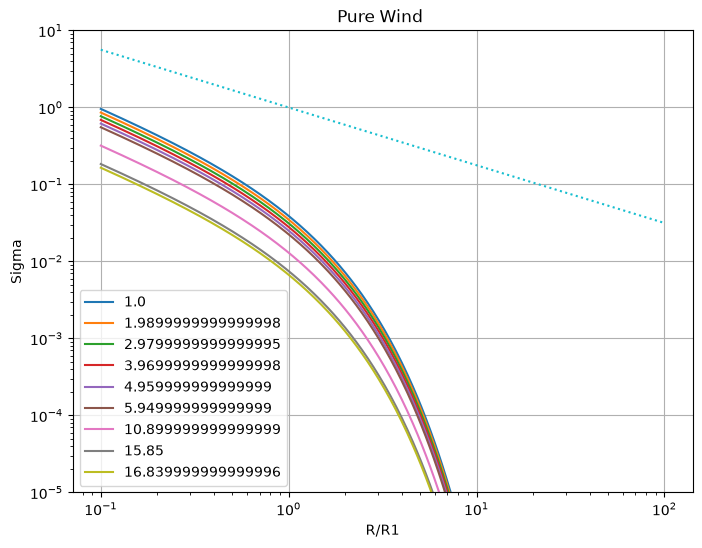

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


nr = 300
r_min, r_max = 1, 100
r = np.logspace(-1,2,400)
dr = r[1] - r[0]

nu0=0.01
nu = nu0*r
R1=1.0
k=1
a=0.01
C=0.01
gamma=1
nu1=nu0*R1
R=r/R1
K=3
Lambda=np.inf
ts=R1**2/(3*(2-gamma)**2 *nu1)
print(ts)

Sigma0=C/(3*np.pi*nu1*R**gamma) *np.exp(-R**(2-gamma))
#print(nu1)


def dSigma_dt(t, Sigma):
    c=k/r**(1/4)
    Omega=K*r**(-3/2)
    A = a*Sigma*c**2/Omega

    dA_dr = np.zeros_like(Sigma)
    #dA_dr[1:-1] = (A[2:] - A[:-2]) / (2 * dr)
    dA_dr = np.gradient(A,r,edge_order=2) 
  
    B = a*Sigma*c**2/(Omega*r**2*2*(Lambda-1))


    #print(dB_dr[-3:])
    #dSigma = np.zeros_like(Sigma)
    #dSigma[1:-1] = (3.0 / r[1:-1]) * dB_dr[1:-1]
    dSigma = (1/r)*dA_dr-B
    #print(dSigma[0],dSigma[-1])


    #dSigma[0] = 0.0
    #dSigma[-1] = 0.0

    return dSigma


t_span = (0, 16*int(ts))
t_eval = np.array([0,1,2,3,4,5,10,15,16])*int(ts)#20,25,30,35,40,45,50]


sol = solve_ivp(
    dSigma_dt,
    t_span,
    Sigma0,
    t_eval=t_eval,
    method='BDF'  
)

R_norm = r/R1 
i1 = np.argmin(np.abs(R_norm - 0.1))
i2 = np.argmin(np.abs(R_norm - 0.3))

sigma = sol.y[:, -1]

slope = (
    np.log10(sigma[i2]) - np.log10(sigma[i1])
) / (
    np.log10(R_norm[i2]) - np.log10(R_norm[i1])
)

print("Log-log slope =", slope)
plt.figure(figsize=(8,6))

for i, t in enumerate(sol.t):
    T = 1 + t/ts
    plt.plot(R_norm, sol.y[:, i], label=T)
plt.plot(R_norm,1/R_norm**(3/4),linestyle=':')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("R/R1")
plt.ylabel("Sigma")
plt.title("Pure Wind ")
plt.legend()
plt.grid()

plt.ylim(1e-5, 10)
plt.show()

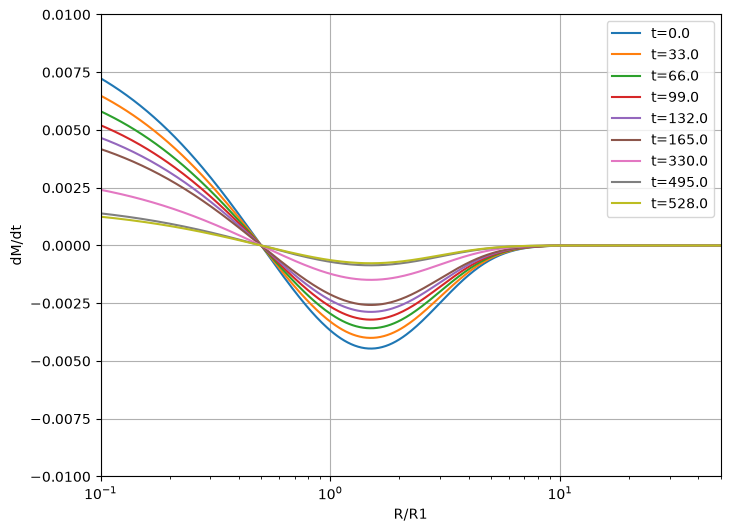

In [11]:
plt.figure(figsize=(8,6))
R1_norm=r/R1
for i, t in enumerate(sol.t):

    Sigma = sol.y[:, i]

    D = nu * Sigma * np.sqrt(r)

    dD_dr = np.gradient(D, r,edge_order=2)

    Mdot = 6*np.pi*np.sqrt(r)*dD_dr

 

    plt.plot(R1_norm, Mdot, label=f"t={t:.1f}")


plt.xlabel("R/R1")
plt.ylabel("dM/dt")
plt.ylim(-0.01,0.01)
plt.xlim(0.1,50)
plt.xscale("log")
#plt.yscale("log")
#plt.ylim(-2.5e-3,2.5e-3)
#plt.xlim(-1,1)
plt.legend()
plt.grid()
plt.show()

33.333333333333336
Log-log slope = -1.1812014350646376


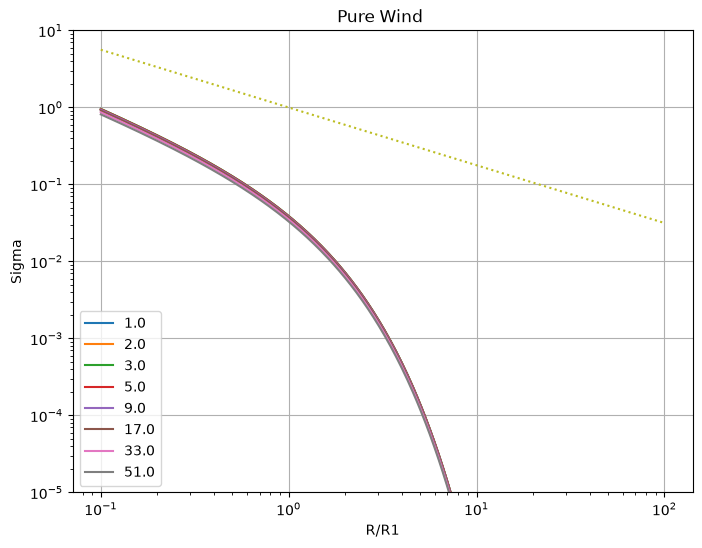

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


nr = 300
r_min, r_max = 1, 100
r = np.logspace(-1,2,400)
dr = r[1] - r[0]

nu0=0.01
nu = nu0*r
R1=1.0
k=1
a=1e-4
C=0.01
gamma=1
nu1=nu0*R1
R=r/R1
K=1
Lambda=np.inf
ts=R1**2/(3*(2-gamma)**2 *nu1)
print(ts)

Sigma0=C/(3*np.pi*nu1*R**gamma) *np.exp(-R**(2-gamma))
#print(nu1)


def dSigma_dt(t, Sigma):
    c=k/r**(1/4)
    Omega=K*r**(-3/2)
    A = a*Sigma*c**2/Omega

    dA_dr = np.zeros_like(Sigma)
    #dA_dr[1:-1] = (A[2:] - A[:-2]) / (2 * dr)
    dA_dr = np.gradient(A,r,edge_order=2) 
  
    B = a*Sigma*c**2/(Omega*r**2*2*(Lambda-1))


    #print(dB_dr[-3:])
    #dSigma = np.zeros_like(Sigma)
    #dSigma[1:-1] = (3.0 / r[1:-1]) * dB_dr[1:-1]
    dSigma = (1/r)*dA_dr-B
    #print(dSigma[0],dSigma[-1])


    #dSigma[0] = 0.0
    #dSigma[-1] = 0.0

    return dSigma


t_span = (0, 50*ts)
t_eval = np.array([0,1,2,4,8,16,32,50])*ts


sol = solve_ivp(
    dSigma_dt,
    t_span,
    Sigma0,
    t_eval=t_eval,
    method='BDF'  
)

R_norm = r/R1 
i1 = np.argmin(np.abs(R_norm - 0.1))
i2 = np.argmin(np.abs(R_norm - 0.3))

sigma = sol.y[:, -1]

slope = (
    np.log10(sigma[i2]) - np.log10(sigma[i1])
) / (
    np.log10(R_norm[i2]) - np.log10(R_norm[i1])
)

print("Log-log slope =", slope)
plt.figure(figsize=(8,6))

for i, t in enumerate(sol.t):
    T = 1 + t/ts
    plt.plot(R_norm, sol.y[:, i], label=T)
plt.plot(R_norm,1/R_norm**(3/4),linestyle=':')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("R/R1")
plt.ylabel("Sigma")
plt.title("Pure Wind ")
plt.legend()
plt.grid()

plt.ylim(1e-5, 10)
plt.show()

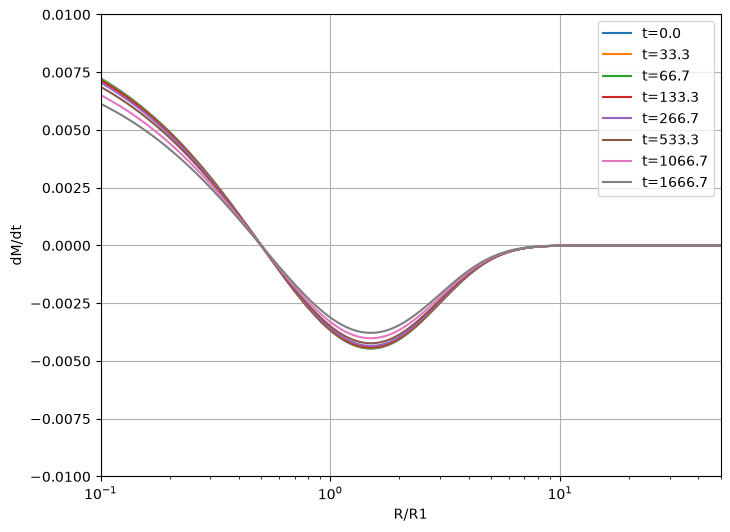

In [14]:
plt.figure(figsize=(8,6))
R1_norm=r/R1
for i, t in enumerate(sol.t):

    Sigma = sol.y[:, i]

    D = nu * Sigma * np.sqrt(r)

    dD_dr = np.gradient(D, r,edge_order=2)

    Mdot = 6*np.pi*np.sqrt(r)*dD_dr

 

    plt.plot(R1_norm, Mdot, label=f"t={t:.1f}")


plt.xlabel("R/R1")
plt.ylabel("dM/dt")
plt.ylim(-0.01,0.01)
plt.xlim(0.1,50)
plt.xscale("log")
#plt.yscale("log")
#plt.ylim(-2.5e-3,2.5e-3)
#plt.xlim(-1,1)
plt.legend()
plt.grid()
plt.show()